##  Time Series Analysis and Modeling with the Air Passengers Dataset


Analyze monthly totals of international airline passengers from 1949 to 1960.
ARMA/ARIMA models will be considered in this analysis.




In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime as dt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima_model import ARIMA
import math
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('AirPassengers.csv')

In [3]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
data['Month'].head()

,Month
0,1949-01
1,1949-02
2,1949-03
3,1949-04
4,1949-05


In [5]:
data['Month'] = data['Month'].apply(lambda x: dt(int(x[:4]), int(x[5:]), 15))
data = data.set_index('Month')
data.head()

,#Passengers
Month,
1949-01-15,112
1949-02-15,118
1949-03-15,132
1949-04-15,129
1949-05-15,121


In [6]:
ts = data['#Passengers']

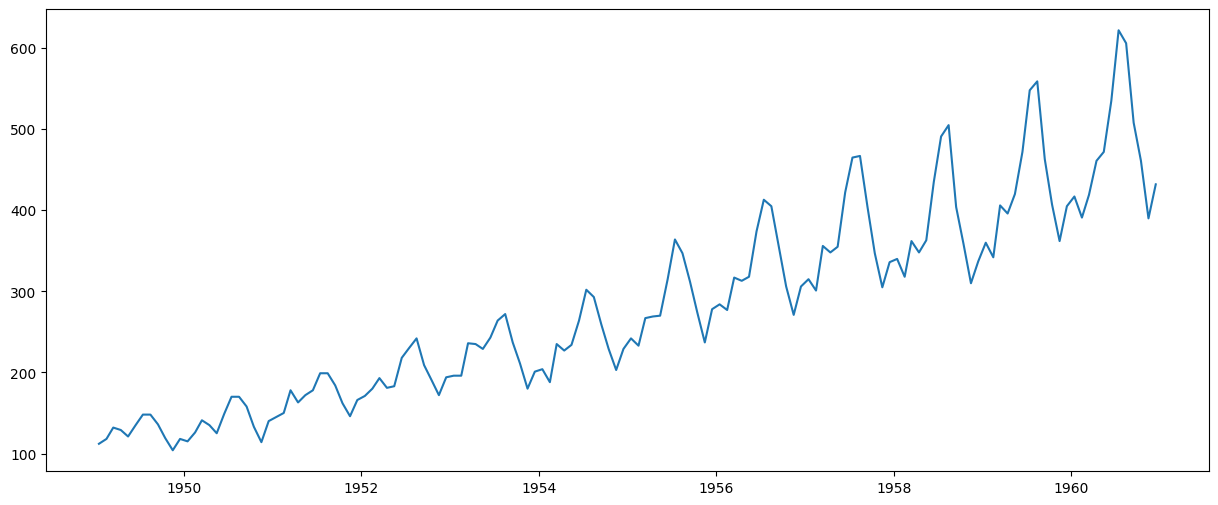

In [7]:
plt.plot(ts)

###  Observe seasonality and trend in the above graph

In [8]:
#transformation
ts_log = np.log(ts)

In [9]:
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=52,center=False).mean()
    rolstd = timeseries.rolling(window=52,center=False).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

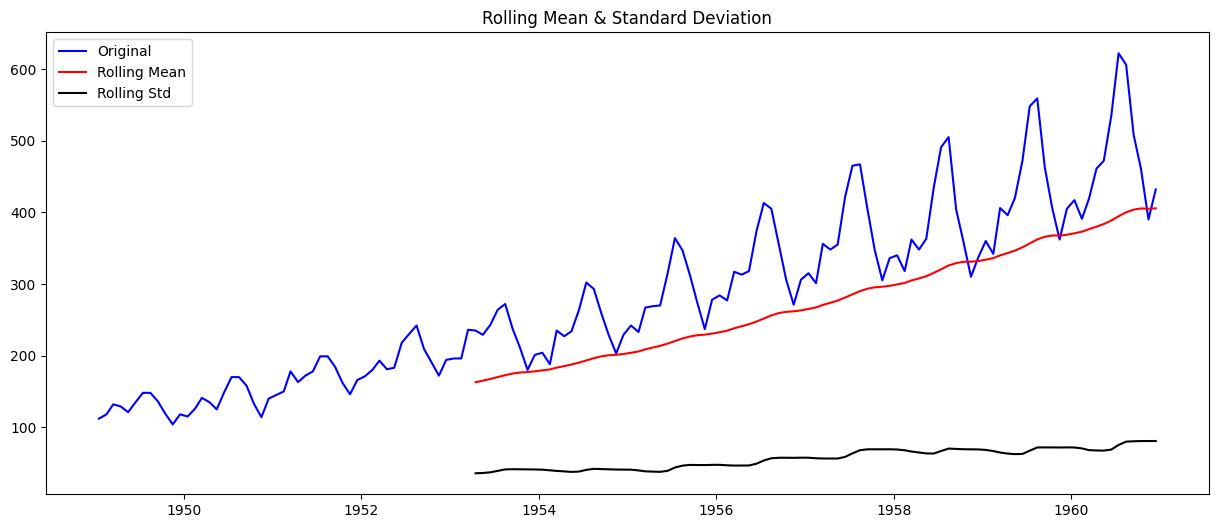

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [10]:
test_stationarity(data['#Passengers'])

###  The time series is not stationary

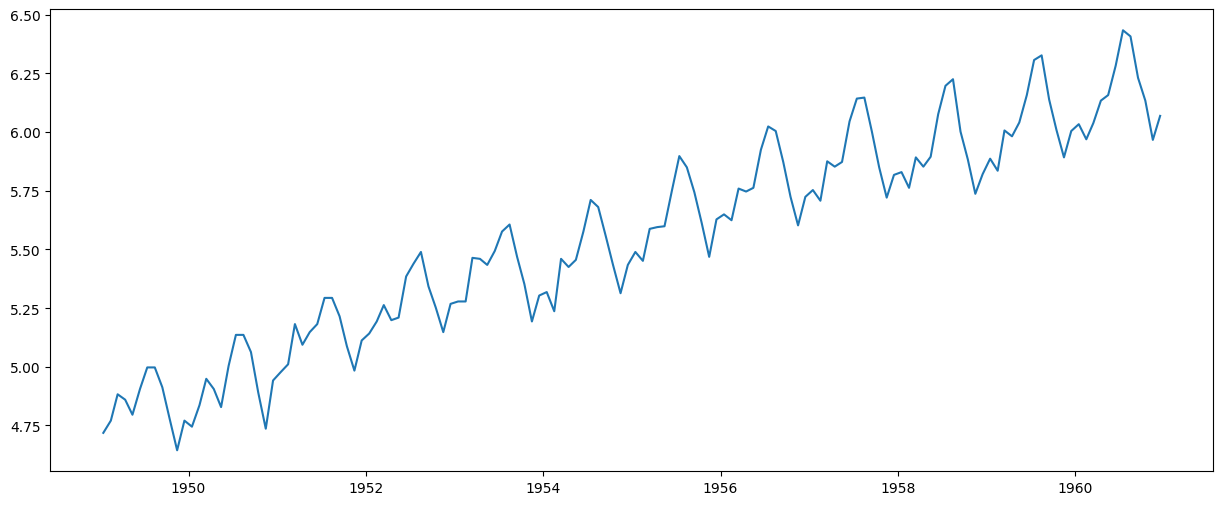

In [11]:
plt.plot(ts_log)

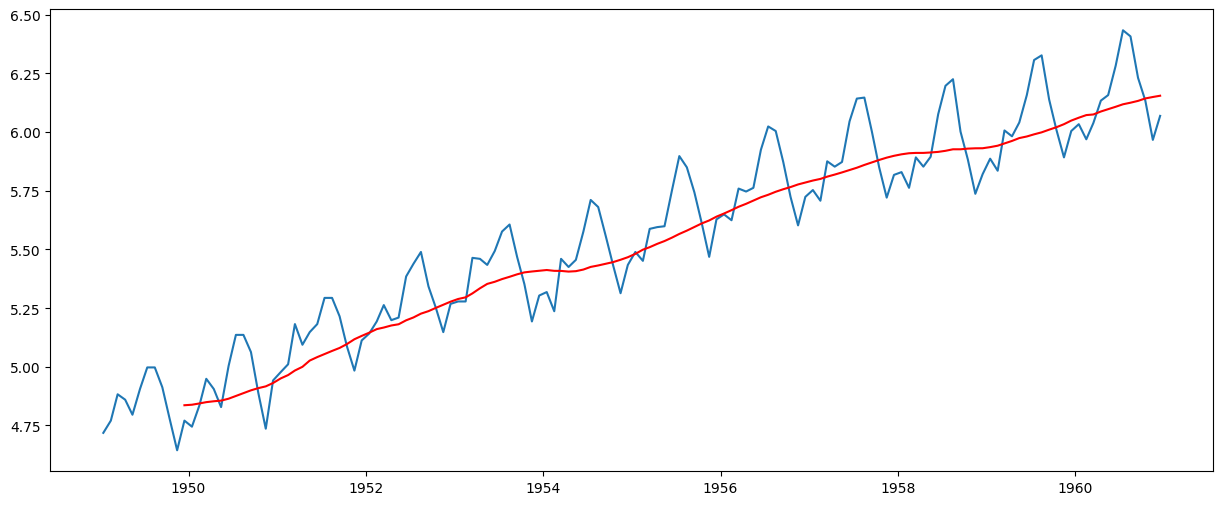

In [12]:
movingAverage = ts_log.rolling(window=12).mean()
movingSTD = ts_log.rolling(window=12).std()
plt.plot(ts_log)
plt.plot(movingAverage, color='red')

In [13]:
# Get the difference between the moving average and the actual number of passengers
ts_log_mv_diff = ts_log - movingAverage
ts_log_mv_diff.head(12)
#Remove Nan Values
ts_log_mv_diff.dropna(inplace=True)
ts_log_mv_diff.head(10)

,#Passengers
Month,
1949-12-15,-0.065494
1950-01-15,-0.093449
1950-02-15,-0.007566
1950-03-15,0.099416
1950-04-15,0.052142
1950-05-15,-0.027529
1950-06-15,0.139881
1950-07-15,0.260184
1950-08-15,0.248635


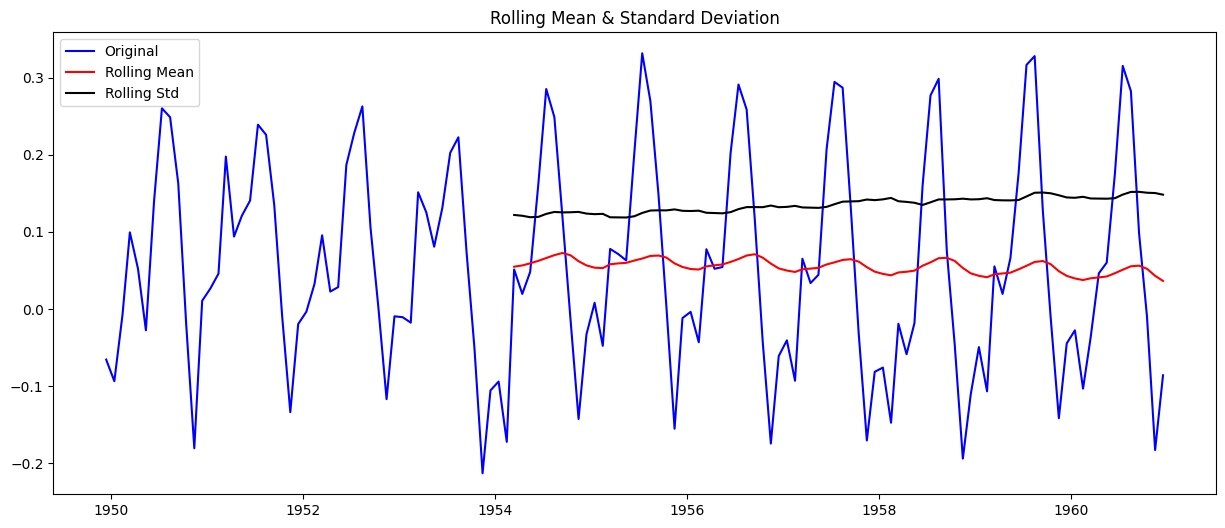

Results of Dickey-Fuller Test:
Test Statistic                  -3.162908
p-value                          0.022235
#Lags Used                      13.000000
Number of Observations Used    119.000000
Critical Value (1%)             -3.486535
Critical Value (5%)             -2.886151
Critical Value (10%)            -2.579896
dtype: float64


In [14]:
test_stationarity(ts_log_mv_diff)

###  The time series is now stationary.

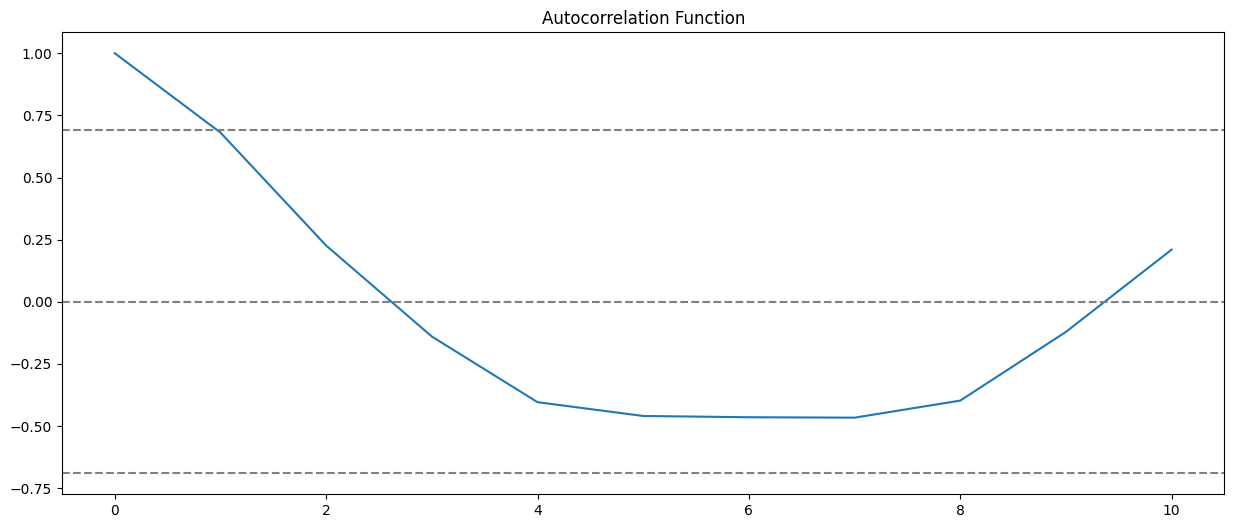

In [15]:
plt.plot(np.arange(0,11), acf(ts_log_mv_diff, nlags = 10))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-7.96/np.sqrt(len(ts_log_mv_diff)),linestyle='--',color='gray')
plt.axhline(y=7.96/np.sqrt(len(ts_log_mv_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')
plt.show()

### The ACF curve crosses the upper confidence value when the lag value is between 0 and 1. Thus, optimal value of q in the ARIMA model must be 0 or 1

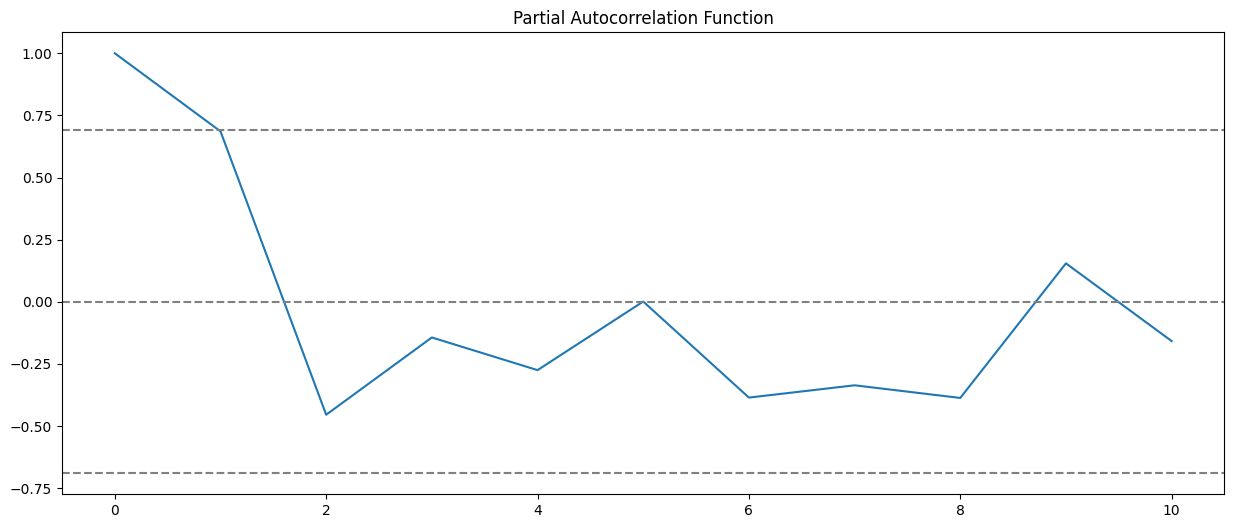

In [16]:
plt.plot(np.arange(0,11), pacf(ts_log_mv_diff, nlags = 10))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-7.96/np.sqrt(len(ts_log_mv_diff)),linestyle='--',color='gray')
plt.axhline(y=7.96/np.sqrt(len(ts_log_mv_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.show()

### The PACF curve drops to 0 between lag values 1 and 2. Thus, optimal value of p in the ARIMA model is 1 or 2.

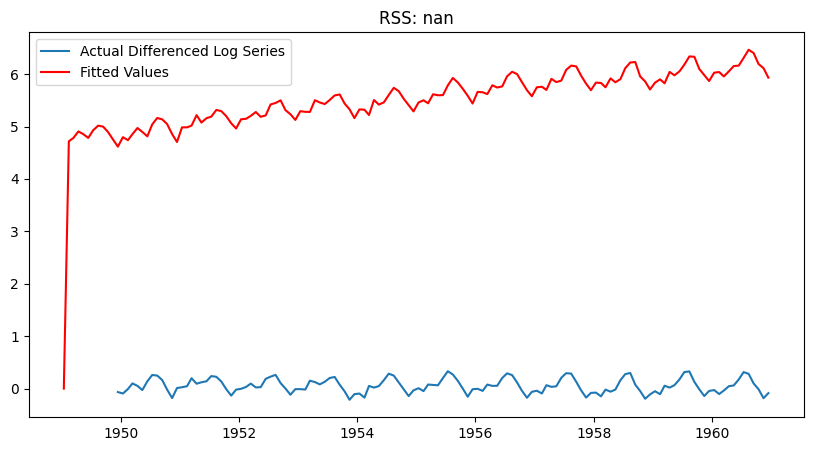

In [17]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# Fit ARIMA
model = ARIMA(ts_log, order=(1, 1, 0))
results_ARIMA = model.fit()

# Plot differenced fitted values vs actual differenced series
plt.figure(figsize=(10, 5))
plt.plot(ts_log_mv_diff, label='Actual Differenced Log Series')
plt.plot(results_ARIMA.fittedvalues, color='red', label='Fitted Values')
plt.legend()
plt.title('RSS: %.4f' % sum((results_ARIMA.fittedvalues[1:] - ts_log_mv_diff[1:])**2))
plt.show()


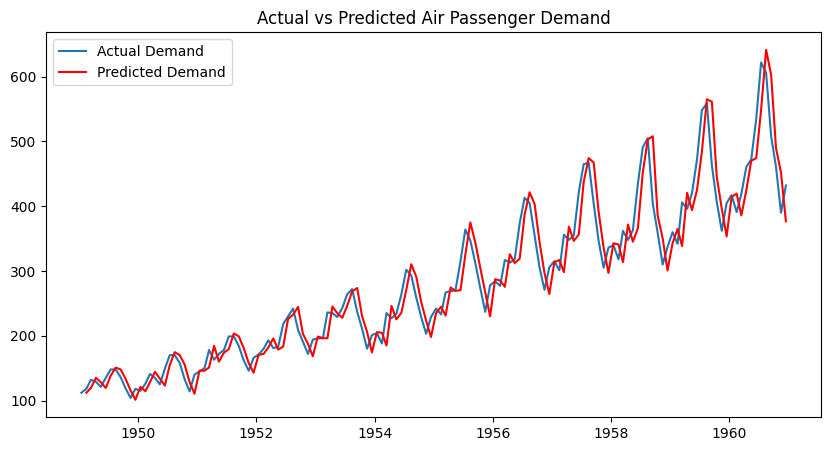

In [18]:
# In-sample prediction on log scale
pred_log = results_ARIMA.predict(start=1, end=len(ts_log)-1, typ='levels')

# Convert back to original scale
pred_original = np.exp(pred_log)

# Actual original series
actual_original = np.exp(ts_log)

# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(actual_original, label='Actual Demand')
plt.plot(pred_original, color='red', label='Predicted Demand')
plt.legend()
plt.title('Actual vs Predicted Air Passenger Demand')
plt.show()


In [19]:
data.tail()

,#Passengers
Month,
1960-08-15,606
1960-09-15,508
1960-10-15,461
1960-11-15,390
1960-12-15,432


In [20]:
# Forecast next 12 periods
forecast_log = results_ARIMA.forecast(steps=12)

# Convert forecast back to original scale
forecast_original = np.exp(forecast_log)

print("Next 12 periods demand forecast:")
print(forecast_original)


Next 12 periods demand forecast:
144    441.172566
145    443.080809
146    443.473829
147    443.554607
148    443.571203
149    443.574612
150    443.575313
151    443.575456
152    443.575486
153    443.575492
154    443.575493
155    443.575494
Name: predicted_mean, dtype: float64


In [21]:
forecast_res = results_ARIMA.get_forecast(steps=12)

forecast_mean_log = forecast_res.predicted_mean
forecast_ci_log = forecast_res.conf_int()

# Convert from log scale back to original scale
forecast_mean = np.exp(forecast_mean_log)
forecast_ci_lower = np.exp(forecast_ci_log.iloc[:, 0])
forecast_ci_upper = np.exp(forecast_ci_log.iloc[:, 1])

forecast_df = pd.DataFrame({
    'Forecasted Demand': forecast_mean,
    'Lower 95% CI': forecast_ci_lower,
    'Upper 95% CI': forecast_ci_upper
})
display(forecast_df)

,Forecasted Demand,Lower 95% CI,Upper 95% CI
144,441.172566,359.599924,541.249371
145,443.080809,321.676943,610.303622
146,443.473829,294.494377,667.819327
147,443.554607,273.565754,719.171486
148,443.571203,256.569029,766.871250
149,443.574612,242.248545,812.217207
150,443.575313,229.871174,855.953595
151,443.575456,218.974955,898.546530
152,443.575486,209.249521,940.309018
153,443.575492,200.475476,981.462777


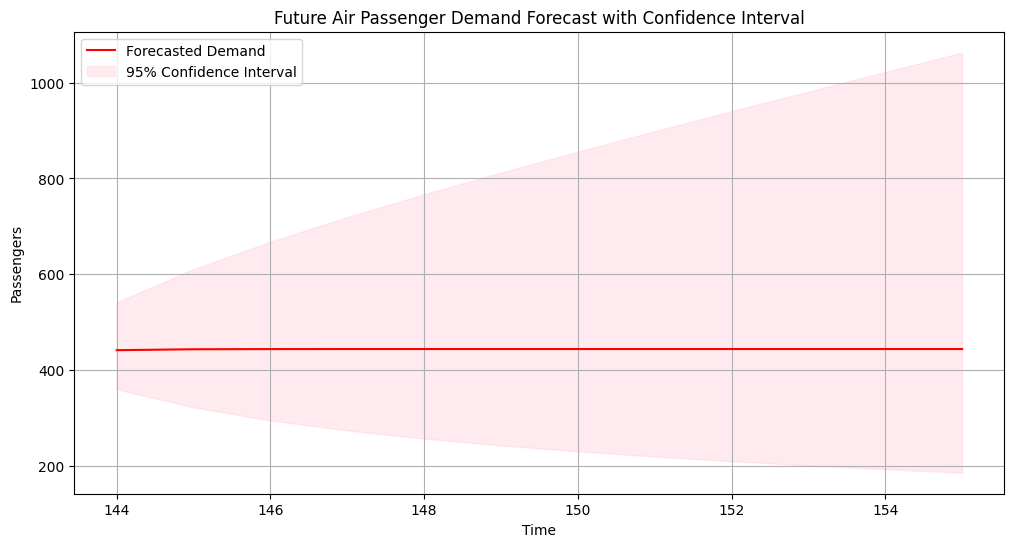

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(forecast_df.index, forecast_df['Forecasted Demand'], label='Forecasted Demand', color='red')
plt.fill_between(
    forecast_df.index,
    forecast_df['Lower 95% CI'],
    forecast_df['Upper 95% CI'],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)
plt.title('Future Air Passenger Demand Forecast with Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value

# ----------------------------
# 1. Forecast future demand
# ----------------------------
model = ARIMA(ts_log, order=(1, 1, 0))
results_ARIMA = model.fit()

forecast_res = results_ARIMA.get_forecast(steps=12)
forecast_mean_log = forecast_res.predicted_mean
forecast_ci_log = forecast_res.conf_int()

# Convert back from log scale
forecast_mean = np.exp(forecast_mean_log)
forecast_lower = np.exp(forecast_ci_log.iloc[:, 0])
forecast_upper = np.exp(forecast_ci_log.iloc[:, 1])

forecast_df = pd.DataFrame({
    "Forecast_Demand": forecast_mean,
    "Lower_CI": forecast_lower,
    "Upper_CI": forecast_upper
})

print("Forecasted demand:")
print(forecast_df)

# ----------------------------
# 2. Optimization model
# ----------------------------
# Decision: how much capacity to allocate each future month

periods = list(range(len(forecast_df)))
demand = forecast_df["Forecast_Demand"].values

# Example business parameters
capacity_cost = 2.0       # cost per allocated seat/unit
shortage_penalty = 8.0    # penalty per unmet passenger/unit
excess_penalty = 1.0      # penalty per unused seat/unit
max_capacity = 700        # upper limit per month

prob = LpProblem("AirPassengerCapacityPlanning", LpMinimize)

capacity = LpVariable.dicts("capacity", periods, lowBound=0, upBound=max_capacity)
shortage = LpVariable.dicts("shortage", periods, lowBound=0)
excess = LpVariable.dicts("excess", periods, lowBound=0)

# Objective: minimize total cost
prob += lpSum(
    capacity_cost * capacity[t] +
    shortage_penalty * shortage[t] +
    excess_penalty * excess[t]
    for t in periods
)

# Balance constraints
for t in periods:
    prob += capacity[t] + shortage[t] - excess[t] == demand[t]

           #d=500 c=450 shortage50, demand=500, capacity=550, excess=50, shortage0

prob.solve()

print("\nOptimization Status:", LpStatus[prob.status])

opt_results = pd.DataFrame({
    "Forecast_Demand": demand,
    "Optimal_Capacity": [value(capacity[t]) for t in periods],
    "Shortage": [value(shortage[t]) for t in periods],
    "Excess": [value(excess[t]) for t in periods]
}, index=forecast_df.index)

print("\nOptimized plan:")
print(opt_results)


Forecasted demand:
     Forecast_Demand    Lower_CI     Upper_CI
144       441.172566  359.599924   541.249371
145       443.080809  321.676943   610.303622
146       443.473829  294.494377   667.819327
147       443.554607  273.565754   719.171486
148       443.571203  256.569029   766.871250
149       443.574612  242.248545   812.217207
150       443.575313  229.871174   855.953595
151       443.575456  218.974955   898.546530
152       443.575486  209.249521   940.309018
153       443.575492  200.475476   981.462777
154       443.575493  192.491398  1022.171487
155       443.575494  185.174690  1062.559996

Optimization Status: Optimal

Optimized plan:
     Forecast_Demand  Optimal_Capacity  Shortage  Excess
144       441.172566         441.17257       0.0     0.0
145       443.080809         443.08081       0.0     0.0
146       443.473829         443.47383       0.0     0.0
147       443.554607         443.55461       0.0     0.0
148       443.571203         443.57120       0.0   

In [24]:
from pulp import LpMaximize

ticket_revenue = 12.0
capacity_cost = 2.0
max_capacity = 700

prob2 = LpProblem("Revenue_Optimization", LpMaximize)

capacity2 = LpVariable.dicts("capacity", periods, lowBound=0, upBound=max_capacity)
served = LpVariable.dicts("served", periods, lowBound=0)

# Maximize revenue from served demand minus capacity cost
prob2 += lpSum(
    ticket_revenue * served[t] - capacity_cost * capacity2[t]
    for t in periods
)

#constraints
for t in periods:  #d=500, c=600
    prob2 += served[t] <= demand[t]
    prob2 += served[t] <= capacity2[t]
#served= min(demand,capacity)
prob2.solve()

opt_results2 = pd.DataFrame({
    "Forecast_Demand": demand,
    "Optimal_Capacity": [value(capacity2[t]) for t in periods],
    "Served_Demand": [value(served[t]) for t in periods]
}, index=forecast_df.index)

print(opt_results2)


""""
c>d, capacity is not at all used
d>c, not all demand served
"""

     Forecast_Demand  Optimal_Capacity  Served_Demand
144       441.172566         441.17257      441.17257
145       443.080809         443.08081      443.08081
146       443.473829         443.47383      443.47383
147       443.554607         443.55461      443.55461
148       443.571203         443.57120      443.57120
149       443.574612         443.57461      443.57461
150       443.575313         443.57531      443.57531
151       443.575456         443.57546      443.57546
152       443.575486         443.57549      443.57549
153       443.575492         443.57549      443.57549
154       443.575493         443.57549      443.57549
155       443.575494         443.57549      443.57549


'"\nc>d, capacity is not at all used\nd>c, not all demand served\n'

In [ ]:
Access 45,000+ models from leading AI providers through a single, unified API with no service fees. Deploy on optimized Inference Endpoints or update your Spaces applications to a GPU in a few clicks. We are building the foundation of ML tooling with the community.

what will